## Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import auc, roc_auc_score, classification_report, accuracy_score, recall_score, f1_score, confusion_matrix

import yaml
import optuna

/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("../params.yaml") as f:
    parameters = yaml.safe_load(f)

DATA = parameters["data"]
FEATURES = parameters["features"]
MODEL = parameters["model"]

NUMERIC = FEATURES["numeric"]
CATEGORICAL = FEATURES["categorical"]
TARGET = FEATURES["target"]

In [3]:
df_train = pd.read_csv(f"{DATA['train_data']}")
df_test = pd.read_csv(f'{DATA["test_data"]}')

### Información proveniente del EDA

In [4]:
with open('./eda_output.txt', 'r') as f:
    eda = f.read()
print(eda)

=== Features Numéricas con Missings ===
- no_of_children (1.7%)
- no_of_days_employed (1.02%)
- yearly_debt_payments (0.21%)
- migrant_worker (0.19%)
- total_family_members (0.18%)
- credit_score (0.02%)

=== Features Categóricas con Missings ===
- owns_car (1.2%)

=== Reporte de Balanceamiento del Target ===
A nivel del dataset train tiene:
- 5% -> Default
- 95% -> No Default
Recomendación: Mirar Recall como kpi principal junto al AUC. Ponderar pesos entre default/nodefault

=== Reporte Feature vs Target ===
Se observa señal algunas señales fuertes que presuntamente indicarían poder predictivo relevante
Algunas de ellas son:
- prev_defaults
- credit_score
- credit_limit_used(%)
- credit_limit
- no_of_days_employed
- net_yearly_income
- gender

=== Reporte de Distribución de Features ===
Se observa que hay muchas features con sesgo hacia la derecha por naturaleza de la variable, 
por ello se recomienda aplicar una log-tranformation o el método WOE en al menos las siguientes:
- no_of_ch

In [5]:
class FeatureEngineering:
    def __init__(self):
        pass
    
    def binning_explore(self, dataset: pd.DataFrame, target: pd.Series, lista_feat: list):
        """Proporciona una tabla resumen de los features respecto a su distribución y event rate
        para hacer los binning manualmente"""
        dataset_merge = dataset.copy()
        dataset_merge["target"] = target
        lista_features = []

        for i in lista_feat:
            #feat = dataset_merge[i].value_counts(normalize = True)
            #event_rate = dataset_merge.groupby(i)["target"].mean()
            dataset_merge['bins'] = pd.qcut(
                x = dataset_merge[i],
                q = 5
            )
            eps = 1e-5
            table = dataset_merge.groupby(
                ['bins'], observed=False
            ).agg(
                total_obs = ("target", "count"),
                total_event = ("target", "sum"),
                event_rate = ("target", "mean")
            )
            table["pct_dist"] = table["total_obs"] / table["total_obs"].sum()
            table["total_no_event"] = table["total_obs"] - table["total_event"]
            table["dist_eventos"] = table["total_event"] / table["total_event"].sum()
            table["dist_no_eventos"] = table["total_no_event"] / table["total_no_event"].sum()
            table["woe"] = (
                np.log( (table["dist_no_eventos"] + eps) / (table["dist_eventos"] + eps) )
            )
            table["feature"] = i

            #table = pd.concat([df_feat, event_rate], axis= 1)
            table = table.reset_index()
            #table = table.sort_values(by=i, ascending= True)
            cols = ['feature'] + [col for col in table.columns if col != 'feature']
            table = table[cols]

            lista_features.append(table)

        return lista_features
    
    def bins_cut(self, dataset: pd.DataFrame, intervalos: list, labels: list, feature: str, target: str):
        """Crea los bins mediante pd.cut y devuelve un dataframe con las nuevas distribuciones y event rate"""
        dataset_merge = dataset.copy()
        
        intervalos_formato = intervalos[1:]
        epsilon = 1e-5

        dataset_merge["bins"] = pd.cut(
            dataset_merge[feature],
            bins= intervalos,
            labels= labels
        )

        agg = dataset_merge.groupby(
            "bins", observed=False
        ).agg(
            n_observaciones = (target, "count"),
            n_eventos = (target, "sum"),
        )
        
        agg["bad_rate"] = agg["n_eventos"] / agg["n_observaciones"]
        agg["pct_obs"] = agg["n_observaciones"] / agg["n_observaciones"].sum()
        agg["n_no_eventos"] = agg["n_observaciones"] - agg["n_eventos"]
        agg["dist_eventos"] = agg["n_eventos"] / agg["n_eventos"].sum()
        agg["dist_no_eventos"] = agg["n_no_eventos"] / agg["n_no_eventos"].sum()
        agg["woe"] = np.log(
            (agg["dist_no_eventos"] + epsilon) / (agg["dist_eventos"] + epsilon)
        )
        agg["iv"] = (agg["dist_no_eventos"] - agg["dist_eventos"]) * agg["woe"]

        table = pd.DataFrame({
            "feature": feature,
            "bin": range(len(agg)),
            "regla": intervalos_formato,
            "n_observaciones": agg["n_observaciones"],
            "pct_obs": agg["pct_obs"],
            "n_eventos": agg["n_eventos"],
            "n_no_eventos": agg["n_no_eventos"],
            "bad_rate": agg["bad_rate"],
            "dist_eventos": agg["dist_eventos"],
            "dist_no_eventos": agg["dist_no_eventos"],
            "WOE":  agg["woe"],
            "IV": agg["iv"]
        })

        print(f"IV del feature: {round(agg['iv'].sum(), 4)}")
        return table
    
    def binning_table(self, dataset: pd.DataFrame, target: pd.Series, feature_bin: str):
        """Proporciona una tabla resumen de los features respecto a su distribución y event rate"""
        dataset_merge = dataset.copy()
        dataset_merge["target"] = target

        eps = 1e-5
        table = dataset_merge.groupby(
            [feature_bin], observed=False
        ).agg(
            total_obs = ("target", "count"),
            total_event = ("target", "sum"),
            event_rate = ("target", "mean")
        )
        table["pct_dist"] = table["total_obs"] / table["total_obs"].sum()
        table["total_no_event"] = table["total_obs"] - table["total_event"]
        table["dist_eventos"] = table["total_event"] / table["total_event"].sum()
        table["dist_no_eventos"] = table["total_no_event"] / table["total_no_event"].sum()
        table["woe"] = (
            np.log( (table["dist_no_eventos"] + eps) / (table["dist_eventos"] + eps) )
        )
        table["feature"] = feature_bin

        #table = pd.concat([df_feat, event_rate], axis= 1)
        table = table.reset_index()
        #table = table.sort_values(by=i, ascending= True)
        cols = ['feature'] + [col for col in table.columns if col != 'feature']
        table = table[cols]

        return table

### Tratamiento de Missings

**Features Numéricas con Missings**
- no_of_children (1.7%) -> indicador de missing 
- no_of_days_employed (1.02%) -> se usará WOE
- yearly_debt_payments (0.21%) -> imputación mediana -> log-transformation
- migrant_worker (0.19%) -> imputación con 0 (valor dominante)
- total_family_members (0.18%) -> imputación mediana -> log-transformation
- credit_score (0.02%) -> se usará WOE

**Features Categóricas con Missings**
- owns_car (1.2%) -> crear categoría de missing

no_of_children (1.7%) -> indicador de missing -> imputación por 0 para Nan feat original

In [6]:
df_train['no_of_children_missing'] = df_train['no_of_children'].isna().astype(int)
df_train.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default,no_of_children_missing
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1,0
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0,0


owns_car (1.2%) -> Crear categoría MISSING

In [7]:
df_train['owns_car'] = df_train['owns_car'].fillna('MISSING')

yearly_debt_payments, total_family_members, no_of_children -> imputación mediana


In [ ]:
FEATS_IMPUTER_MEDIAN = ['yearly_debt_payments', 'total_family_members', 'credit_limit']
# agrego credit_limit porque sigue ese pipeline

migrant_worker (0.19%) -> imputación con 0 (valor dominante)

In [ ]:
FEATS_IMPUTER_ZERO = ['no_of_children', 'migrant_worker']

### Log-Transformación

In [8]:
LOG_TRANSFORM = ['credit_limit', 'total_family_members', 'yearly_debt_payments', 'net_yearly_income']

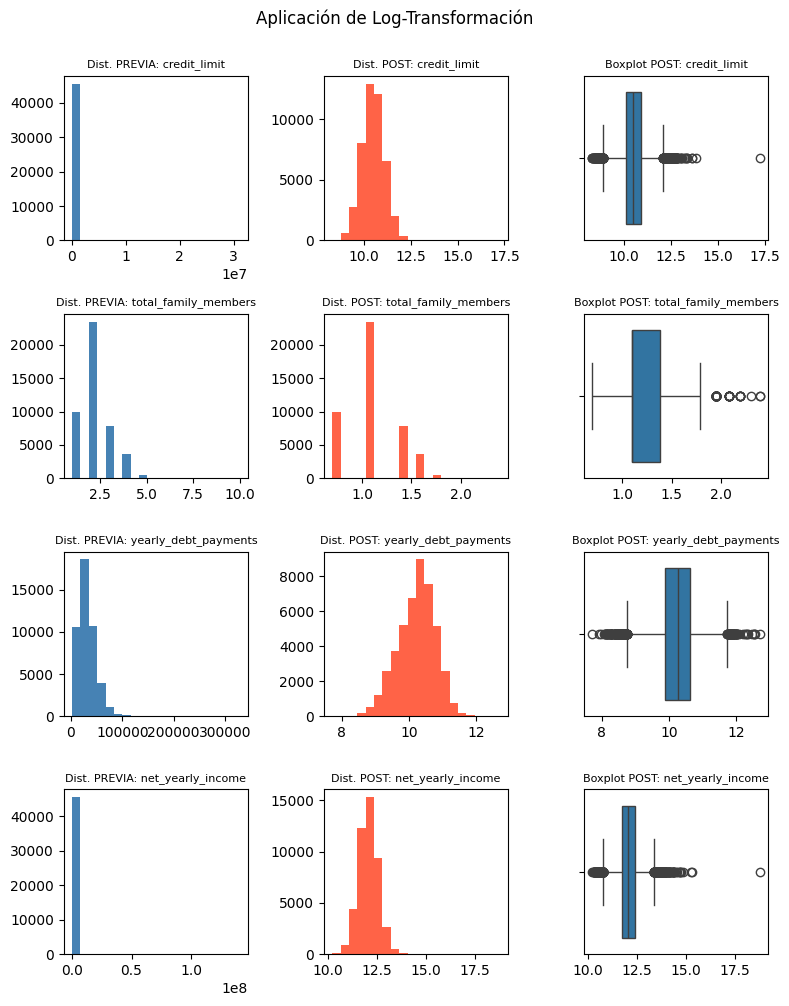

In [9]:
for i in LOG_TRANSFORM:
    df_train[f'{i}_log'] = np.log1p(df_train[i])

n_cols = 3
n_rows = ((len(LOG_TRANSFORM * 3) - 1) // 3 ) + 1
fig, axes = plt.subplots(ncols = n_cols, nrows = n_rows, figsize = (8, 2.5 * n_rows))

for i, feat in enumerate(LOG_TRANSFORM):
    axes[i, 0].hist(
        x = df_train[feat],
        bins = 20,
        color = 'steelblue'
    )
    axes[i, 0].set_title(f'Dist. PREVIA: {feat}', fontsize = 8)

    axes[i, 1].hist(
        x = df_train[f'{feat}_log'],
        bins = 20,
        color = 'tomato'
    )
    axes[i, 1].set_title(f'Dist. POST: {feat}', fontsize = 8)

    sns.boxplot(
        x = df_train[f'{feat}_log'],
        ax = axes[i, 2]
    )
    axes[i, 2].set_title(f'Boxplot POST: {feat}', fontsize =8)
    axes[i, 2].set_xlabel('')

plt.suptitle('Aplicación de Log-Transformación', y = 1.001)
plt.tight_layout()
plt.show()

# sns.histplot(data = df_train, x = 'credit_limit_log')

### Aplicar la transformación WOE

In [10]:
WOE_TRANSFORM = ['no_of_days_employed', 'credit_limit_used(%)', 'credit_score']

Binning Exploración

In [11]:
model_1 = FeatureEngineering()

In [12]:
bins_exploration = model_1.binning_explore(
    dataset = df_train[WOE_TRANSFORM],
    target = df_train[TARGET],
    lista_feat = WOE_TRANSFORM
)
for i in bins_exploration:
    display(i)

,feature,bins,total_obs,total_event,event_rate,pct_dist,total_no_event,dist_eventos,dist_no_eventos,woe
0,no_of_days_employed,"(1.999, 747.0]",9019,635,0.070407,0.200133,8384,0.278387,0.195961,-0.351080
1,no_of_days_employed,"(747.0, 1605.0]",9008,562,0.062389,0.199889,8446,0.246383,0.197410,-0.221594
2,no_of_days_employed,"(1605.0, 3074.4]",9012,470,0.052153,0.199978,8542,0.206050,0.199654,-0.031531
3,no_of_days_employed,"(3074.4, 9238.0]",9015,312,0.034609,0.200044,8703,0.136782,0.203417,0.396846
4,no_of_days_employed,"(9238.0, 365252.0]",9011,302,0.033515,0.199956,8709,0.132398,0.203557,0.430109


,feature,bins,total_obs,total_event,event_rate,pct_dist,total_no_event,dist_eventos,dist_no_eventos,woe
0,credit_limit_used(%),"(-0.001, 21.0]",9227,0,0.000000,0.202666,9227,0.000000,0.213455,9.968641
1,credit_limit_used(%),"(21.0, 43.0]",9244,0,0.000000,0.203040,9244,0.000000,0.213848,9.970482
2,credit_limit_used(%),"(43.0, 65.0]",9218,0,0.000000,0.202469,9218,0.000000,0.213246,9.967665
3,credit_limit_used(%),"(65.0, 83.0]",9203,1064,0.115614,0.202139,8139,0.462408,0.188285,-0.898458
4,credit_limit_used(%),"(83.0, 99.0]",8636,1237,0.143238,0.189685,7399,0.537592,0.171166,-1.144426


,feature,bins,total_obs,total_event,event_rate,pct_dist,total_no_event,dist_eventos,dist_no_eventos,woe
0,credit_score,"(499.999, 689.0]",9146,2300,0.251476,0.200923,6846,1.0,0.158399,-1.842586
1,credit_score,"(689.0, 753.0]",9150,0,0.000000,0.201011,9150,0.0,0.211708,9.960423
2,credit_score,"(753.0, 818.0]",9068,0,0.000000,0.199209,9068,0.0,0.209810,9.951422
3,credit_score,"(818.0, 883.0]",9063,0,0.000000,0.199099,9063,0.0,0.209695,9.950870
4,credit_score,"(883.0, 949.0]",9093,0,0.000000,0.199758,9093,0.0,0.210389,9.954175


In [13]:
table_credit_limit_used = model_1.bins_cut(
    dataset = df_train,
    labels = ['<80%', '>80%'],
    intervalos = [-np.inf, 80 , np.inf],
    feature = 'credit_limit_used(%)',
    target = TARGET
    
)
table_credit_limit_used

IV del feature: 0.8397


,feature,bin,regla,n_observaciones,pct_obs,n_eventos,n_no_eventos,bad_rate,dist_eventos,dist_no_eventos,WOE,IV
bins,,,,,,,,,,,,
<80%,credit_limit_used(%),0,80.0,35236,0.773941,831,34405,0.023584,0.361147,0.795915,0.790191,0.343549
>80%,credit_limit_used(%),1,inf,10292,0.226059,1470,8822,0.142829,0.638853,0.204085,-1.141102,0.496114


In [14]:
table_credit_score = model_1.bins_cut(
    dataset = df_train,
    labels = ['<550', '>550'],
    intervalos = [-np.inf, 550, np.inf],
    #intervalos = [-np.inf, 499, 700, np.inf],
    feature = 'credit_score',
    target = TARGET
)
table_credit_score

IV del feature: 0.5258


,feature,bin,regla,n_observaciones,pct_obs,n_eventos,n_no_eventos,bad_rate,dist_eventos,dist_no_eventos,WOE,IV
bins,,,,,,,,,,,,
<550,credit_score,0,550.0,937,0.020584,433,504,0.462113,0.188261,0.011661,-2.780752,0.491080
>550,credit_score,1,inf,44583,0.979416,1867,42716,0.041877,0.811739,0.988339,0.196844,0.034763


**Transformación con WOE**

credit_limit_used(%)

In [15]:
# credit_limit_used(%) -> 0% missings
df_train["credit_limit_used(%)_bin"] = pd.cut(
    x= df_train['credit_limit_used(%)'],
    bins= [-np.inf, 80 , np.inf],
)

table = model_1.binning_table(
    dataset= df_train.drop(columns= [TARGET], axis = 1),
    target = df_train[TARGET],
    feature_bin= 'credit_limit_used(%)_bin'
)

woe_map = dict(zip(table['credit_limit_used(%)_bin'], table['woe']))
df_train['credit_limit_used(%)_woe'] = df_train['credit_limit_used(%)_bin'].map(woe_map)

no_of_days_employed

In [16]:
# no_of_days_employed -> (1.02% missings)
df_train["no_of_days_employed_bin"] = pd.cut(
    x= df_train['no_of_days_employed'],
    bins= [-np.inf, 747, 1605, 3074, 9238, np.inf],
)
df_train["no_of_days_employed_bin"] = df_train["no_of_days_employed_bin"].astype(object)
df_train.loc[df_train["no_of_days_employed"].isna(), "no_of_days_employed_bin"] = "MISSING"

table_days_employed = model_1.binning_table(
    dataset= df_train.drop(columns= [TARGET], axis= 1),
    target= df_train[TARGET],
    feature_bin= 'no_of_days_employed_bin'
)

woe_map = dict(zip(table_days_employed['no_of_days_employed_bin'], table_days_employed['woe']))
df_train["no_of_days_employed_woe"] = df_train['no_of_days_employed_bin'].map(woe_map)

In [17]:
# credit_score -> (0.02% missings)
df_train["credit_score_bin"] = pd.cut(
    x= df_train['credit_score'],
    bins= [-np.inf, 550, np.inf],
)

df_train['credit_score_bin'] = df_train['credit_score_bin'].astype(object)
df_train.loc[df_train['credit_score'].isna(), 'credit_score_bin'] = "MISSING"

table = model_1.binning_table(
    dataset= df_train.drop(columns= [TARGET], axis = 1),
    target = df_train[TARGET],
    feature_bin= 'credit_score_bin'
)

woe_map = dict(zip(table['credit_score_bin'], table['woe']))
df_train['credit_score_woe'] = df_train['credit_score_bin'].map(woe_map)

### Pipeline finales

In [19]:
FEATS_NUM_WOE = ['credit_limit_used(%)_woe', 'no_of_days_employed_woe', 'credit_score_woe'] # solo agregar
FEATS_NUM_LOG_TRANS = ['credit_limit', 'total_family_members', 'yearly_debt_payments', 'net_yearly_income'] # Sin crear aún - check
FEATS_CATEGORICALS = ['gender', 'owns_car', 'owns_house', 'occupation_type'] # check
FEATS_MISSINGS = ['no_of_children_missing'] # SOLO AGREGAR
FEATS_NUM_IMP_ZERO = ['migrant_worker'] # check
FEATS_NUM_IMP_ZERO_SCALING = ['no_of_children'] # check
FEATS_OTROS_NUM_SCALING = ['age'] 
FEATS_OTROS_BINARY = ['prev_defaults']

#### Pipeline TRAIN

In [43]:
pipe_num_median_logtrans = Pipeline(
    steps= [
        ('imputer_median', SimpleImputer(strategy = 'median')),
        # omitir por ahora tratamiento de outliers
        ('log_transformation', FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ('standar_scaler', StandardScaler())
    ]
)

pipe_num_zero = Pipeline(
    steps = [
        ('imputer_zero', SimpleImputer(strategy = 'constant', fill_value = 0))
    ]
)

pipe_num_zero_scaling = Pipeline(
    steps = [
        ('imputer_zero', SimpleImputer(strategy = 'constant', fill_value = 0)),
        ('standar_scaler', StandardScaler())
    ]
)

pipe_encoding = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ('ohe', OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

pipe_num_otros_scaling = Pipeline(
    steps = [
        ('standar_scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ('num_median_logtrans', pipe_num_median_logtrans, FEATS_NUM_LOG_TRANS),
        ('num_zero', pipe_num_zero, FEATS_NUM_IMP_ZERO),
        ('num_zero_scaling', pipe_num_zero_scaling, FEATS_NUM_IMP_ZERO_SCALING),
        ('ohe_encoder', pipe_encoding, FEATS_CATEGORICALS),
        ('num_otros_scaling', pipe_num_otros_scaling, FEATS_OTROS_NUM_SCALING),
        ('woe', 'passthrough', FEATS_NUM_WOE),
        ('missing', 'passthrough', FEATS_MISSINGS),
        ('binary', 'passthrough', FEATS_OTROS_BINARY)
    ]
)

model_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter = 1000,
            class_weight= 'balanced',
            random_state = 42
        ))
    ]
)

In [44]:
X_train = df_train[FEATS_NUM_WOE + FEATS_NUM_LOG_TRANS + FEATS_CATEGORICALS + FEATS_MISSINGS + FEATS_NUM_IMP_ZERO + FEATS_NUM_IMP_ZERO_SCALING + FEATS_OTROS_NUM_SCALING + FEATS_OTROS_BINARY]
y_train = df_train[TARGET]
X_train

,credit_limit_used(%)_woe,no_of_days_employed_woe,credit_score_woe,credit_limit,total_family_members,yearly_debt_payments,net_yearly_income,gender,owns_car,owns_house,occupation_type,no_of_children_missing,migrant_worker,no_of_children,age,prev_defaults
0,0.790191,-0.352651,-2.780479,18690.93,1.0,33070.28,107934.04,F,N,Y,Unknown,0,1.0,0.0,46,2
1,0.790191,-0.033102,0.197117,37745.19,2.0,15329.53,109862.62,M,N,Y,Laborers,0,0.0,0.0,29,0
2,0.790191,-0.352651,0.197117,41598.36,2.0,48416.60,230153.17,M,N,Y,Laborers,0,0.0,0.0,37,0
3,0.790191,0.428537,0.197117,32627.76,2.0,22574.36,122325.82,F,N,Y,Core staff,0,0.0,0.0,39,0
4,0.790191,-0.223165,0.197117,52950.64,1.0,38282.95,387286.00,M,Y,Y,Core staff,0,0.0,0.0,46,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45523,-1.141102,-0.352651,0.197117,29663.83,4.0,11229.54,96207.57,F,N,N,Unknown,0,0.0,2.0,55,0
45524,0.790191,-0.223165,0.197117,139947.16,2.0,43369.91,383476.74,F,N,Y,Accountants,0,1.0,0.0,31,0
45525,0.790191,-0.223165,0.197117,83961.83,2.0,22707.51,260052.18,F,N,Y,Core staff,0,0.0,0.0,27,0
45526,-1.141102,-0.033102,0.197117,25538.72,2.0,20150.10,157363.04,M,Y,N,Laborers,0,0.0,0.0,32,0


In [45]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_median_logtrans', ...), ('num_zero', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

In [46]:
predictions_train = model_pipeline.predict(X_train)
predictions_train_proba = model_pipeline.predict_proba(X_train)[:, 1]
predictions_train_proba

array([0.99999998, 0.01258926, 0.01329798, ..., 0.01115326, 0.02025028,
       0.01087208], shape=(45528,))

In [55]:
print(f'TRAIN Accuracy: {accuracy_score(y_train, predictions_train)}')
print(f'TRAIN Recall: {recall_score(y_train, predictions_train)}')
print(f'TRAIN F1: {f1_score(y_train, predictions_train)}')
print(f'TRAIN AUC: {roc_auc_score(y_train, predictions_train_proba)}')
#print(f'TRAIN GINI: {2 * (roc_auc_score(y_train, predictions_train_proba)) - 1}')

TRAIN Accuracy: 0.988929889298893
TRAIN Recall: 1.0
TRAIN F1: 0.9012925969447708
TRAIN AUC: 0.9929960115649145


In [49]:
print(classification_report(y_train, predictions_train))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     43227
           1       0.82      1.00      0.90      2301

    accuracy                           0.99     45528
   macro avg       0.91      0.99      0.95     45528
weighted avg       0.99      0.99      0.99     45528



#### Pipeline TEST

In [27]:
df_test.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months
0,CST_142525,Siva,52,F,Y,N,0.0,232640.53,998.0,Unknown,2.0,0.0,14406.73,26524.40,4,779.0,0,0
1,CST_129215,Scott,48,F,N,N,1.0,284396.79,1338.0,Unknown,3.0,0.0,57479.99,68998.72,70,806.0,0,0
2,CST_138443,Victoria,50,F,N,N,1.0,149419.28,1210.0,Unknown,3.0,0.0,21611.01,25187.80,71,528.0,2,0
3,CST_123812,John McCrank,30,F,N,N,1.0,160437.54,503.0,Laborers,2.0,1.0,28990.76,29179.39,9,815.0,0,0
4,CST_144450,Martinne,52,M,N,Y,0.0,233480.37,157.0,Laborers,2.0,1.0,54213.72,82331.82,82,613.0,1,1


WOE

In [28]:
# credit_limit_used(%) -> 0% missings
df_test["credit_limit_used(%)_bin"] = pd.cut(
    x= df_test['credit_limit_used(%)'],
    bins= [-np.inf, 80 , np.inf],
)

table = model_1.binning_table(
    dataset= df_test.drop(columns= [TARGET], axis = 1),
    target = df_test[TARGET],
    feature_bin= 'credit_limit_used(%)_bin'
)

woe_map = dict(zip(table['credit_limit_used(%)_bin'], table['woe']))
df_test['credit_limit_used(%)_woe'] = df_test['credit_limit_used(%)_bin'].map(woe_map)

In [29]:
# no_of_days_employed -> (1.02% missings)
df_test["no_of_days_employed_bin"] = pd.cut(
    x= df_test['no_of_days_employed'],
    bins= [-np.inf, 747, 1605, 3074, 9238, np.inf],
)
df_test["no_of_days_employed_bin"] = df_test["no_of_days_employed_bin"].astype(object)
df_test.loc[df_test["no_of_days_employed"].isna(), "no_of_days_employed_bin"] = "MISSING"

table_days_employed = model_1.binning_table(
    dataset= df_test.drop(columns= [TARGET], axis= 1),
    target= df_test[TARGET],
    feature_bin= 'no_of_days_employed_bin'
)

woe_map = dict(zip(table_days_employed['no_of_days_employed_bin'], table_days_employed['woe']))
df_test["no_of_days_employed_woe"] = df_test['no_of_days_employed_bin'].map(woe_map)

In [30]:
# credit_score -> (0.02% missings)
df_test["credit_score_bin"] = pd.cut(
    x= df_test['credit_score'],
    bins= [-np.inf, 550, np.inf],
)

df_test['credit_score_bin'] = df_test['credit_score_bin'].astype(object)
df_test.loc[df_test['credit_score'].isna(), 'credit_score_bin'] = "MISSING"

table = model_1.binning_table(
    dataset= df_test.drop(columns= [TARGET], axis = 1),
    target = df_test[TARGET],
    feature_bin= 'credit_score_bin'
)

woe_map = dict(zip(table['credit_score_bin'], table['woe']))
df_test['credit_score_woe'] = df_test['credit_score_bin'].map(woe_map)

Indicador de Missing

In [31]:
df_test['no_of_children_missing'] = df_test['no_of_children'].isna().astype(int)
df_test.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,...,credit_score,prev_defaults,default_in_last_6months,credit_limit_used(%)_bin,credit_limit_used(%)_woe,no_of_days_employed_bin,no_of_days_employed_woe,credit_score_bin,credit_score_woe,no_of_children_missing
0,CST_142525,Siva,52,F,Y,N,0.0,232640.53,998.0,Unknown,...,779.0,0,0,"(-inf, 80.0]",0.825547,"(747.0, 1605.0]",-0.269934,"(550.0, inf]",0.200769,0
1,CST_129215,Scott,48,F,N,N,1.0,284396.79,1338.0,Unknown,...,806.0,0,0,"(-inf, 80.0]",0.825547,"(747.0, 1605.0]",-0.269934,"(550.0, inf]",0.200769,0
2,CST_138443,Victoria,50,F,N,N,1.0,149419.28,1210.0,Unknown,...,528.0,2,0,"(-inf, 80.0]",0.825547,"(747.0, 1605.0]",-0.269934,"(-inf, 550.0]",-3.040760,0
3,CST_123812,John McCrank,30,F,N,N,1.0,160437.54,503.0,Laborers,...,815.0,0,0,"(-inf, 80.0]",0.825547,"(-inf, 747.0]",-0.315573,"(550.0, inf]",0.200769,0
4,CST_144450,Martinne,52,M,N,Y,0.0,233480.37,157.0,Laborers,...,613.0,1,1,"(80.0, inf]",-1.175945,"(-inf, 747.0]",-0.315573,"(550.0, inf]",0.200769,0


In [32]:
X_test = df_test[
    FEATS_NUM_WOE 
    + FEATS_NUM_LOG_TRANS 
    + FEATS_CATEGORICALS 
    + FEATS_MISSINGS 
    + FEATS_NUM_IMP_ZERO 
    + FEATS_NUM_IMP_ZERO_SCALING 
    + FEATS_OTROS_NUM_SCALING 
    + FEATS_OTROS_BINARY
]

y_test = df_test[TARGET]

In [50]:
predictions_test = model_pipeline.predict(X_test)
predictions_test_proba = model_pipeline.predict_proba(X_test)[:, 1]

In [51]:
print(f'TEST Accuracy: {accuracy_score(y_test, predictions_test)}')
print(f'TEST Recall: {recall_score(y_test, predictions_test)}')
print(f'TEST F1: {f1_score(y_test, predictions_test)}')
print(f'TEST AUC: {roc_auc_score(y_test, predictions_test_proba)}')

TEST Accuracy: 0.9913906702978126
TEST Recall: 1.0
TEST F1: 0.9187396351575456
TEST AUC: 0.9945116619266423


In [52]:
print(classification_report(y_test, predictions_test))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     10829
           1       0.85      1.00      0.92       554

    accuracy                           0.99     11383
   macro avg       0.92      1.00      0.96     11383
weighted avg       0.99      0.99      0.99     11383



In [53]:
model = model_pipeline.named_steps["model"]
coefs = model.coef_[0]
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
})

coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_df.head(20)

,feature,coef,abs_coef
38,binary__prev_defaults,8.455586,8.455586
36,woe__credit_score_woe,-1.912793,1.912793
6,ohe_encoder__gender_F,-0.882622,0.882622
13,ohe_encoder__owns_house_Y,-0.802296,0.802296
12,ohe_encoder__owns_house_N,-0.791212,0.791212
7,ohe_encoder__gender_M,-0.709691,0.709691
11,ohe_encoder__owns_car_Y,-0.652489,0.652489
24,ohe_encoder__occupation_type_Managers,-0.590521,0.590521
10,ohe_encoder__owns_car_N,-0.472425,0.472425
9,ohe_encoder__owns_car_MISSING,-0.468593,0.468593


In [56]:
##